# Gender+Lexrank on rule based

In [ ]:
# Install spacy if not already installed
!pip install spacy pandas openpyxl

# Import libraries
import spacy
import pandas as pd

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import pandas as pd

# Load full dataset
file_path = "/content/sample_data/output.xlsx"
df = pd.read_excel(file_path)

# Keep only clean_text column (still as DataFrame)
df = df[["cf_w2v"]].dropna()

# Check
df.head()

,cf_w2v
0,take that .... this me too is a well orchestra...
1,only 40 charges and thousands of cries for hel...
2,former cricketer and cricket association of Be...
3,my dream is that one day everyone will know wh...
4,"still,better than my neighbour or'stalker' as ..."


In [ ]:
# Define gender-specific keywords
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}

# Function to classify gender based on Spacy NER
def classify_gender_ner(text):
    doc = nlp(str(text))  # Process text with Spacy

    male_count = sum(1 for token in doc if token.text.lower() in male_terms)
    female_count = sum(1 for token in doc if token.text.lower() in female_terms)

    if male_count > female_count:
        return "Male"
    elif female_count > male_count:
        return "Female"
    elif male_count == female_count and male_count > 0:
        return "Both"
    else:
        return "Neutral/Unclear"


In [ ]:
df["Gender_Category"] = df["cf_w2v"].astype(str).apply(classify_gender_ner)
df.head(50)

,cf_w2v,Gender_Category
0,take that .... this me too is a well orchestra...,Female
1,only 40 charges and thousands of cries for hel...,Neutral/Unclear
2,former cricketer and cricket association of Be...,Neutral/Unclear
3,my dream is that one day everyone will know wh...,Neutral/Unclear
4,"still,better than my neighbour or'stalker' as ...",Female
5,louis ck now stands also as short-form.,Neutral/Unclear
6,if you excuse your boys behavior you create an...,Male
7,since my moment: * someone tried to unsuccessf...,Neutral/Unclear
8,"sharman joshi opens up on : \""maligning someon...",Neutral/Unclear
9,"is a movement toward victimization, g.o.p. sen...",Neutral/Unclear


In [ ]:
print(df.columns)

Index(['cf_w2v', 'Gender_Category'], dtype='object')


In [ ]:
# Create separate DataFrames
male_tweets = df[df["Gender_Category"] == "Male"]
female_tweets = df[df["Gender_Category"] == "Female"]
both_tweets = df[df["Gender_Category"] == "Neutral/Unclear"]

In [ ]:
print("Male:", len(male_tweets))
print("Female:", len(female_tweets))
print("Both:", len(both_tweets))

Male: 201
Female: 66
Both: 191


In [ ]:
male_tweets = male_tweets[["cf_w2v"]]
female_tweets = female_tweets[["cf_w2v"]]
both_tweets = both_tweets[["cf_w2v"]]

In [ ]:
male_tweets.to_excel("/content/sample_data/male_tweets.xlsx", index=False)
female_tweets.to_excel("/content/sample_data/female_tweets.xlsx", index=False)
both_tweets.to_excel("/content/sample_data/both_tweets.xlsx", index=False)

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def compute_similarity_bert(texts):
    # Encode sentences → embeddings
    embeddings = model.encode(texts, convert_to_numpy=True)

    # Cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings)

    return similarity_matrix

In [ ]:
male_texts = male_tweets["cf_w2v"].astype(str).tolist()
female_texts = female_tweets["cf_w2v"].astype(str).tolist()
both_texts = both_tweets["cf_w2v"].astype(str).tolist()

In [ ]:
male_sim = compute_similarity_bert(male_texts)
female_sim = compute_similarity_bert(female_texts)
both_sim = compute_similarity_bert(both_texts)

In [ ]:
def create_pairs(texts, sim_matrix):
    pairs = []

    n = len(texts)

    for i in range(n):
        for j in range(i + 1, n):   # avoid duplicates + self-pairs
            pairs.append({
                "Tweet 1": texts[i],
                "Tweet 2": texts[j],
                "Similarity Score": sim_matrix[i][j]
            })

    return pd.DataFrame(pairs)

In [ ]:
male_similarity_df = create_pairs(male_texts, male_sim)
female_similarity_df = create_pairs(female_texts, female_sim)
both_similarity_df = create_pairs(both_texts, both_sim)

In [ ]:
male_similarity_df.head()

,Tweet 1,Tweet 2,Similarity Score
0,if you excuse your boys behavior you create an...,thanks for being the rare voice in the industr...,0.093923
1,if you excuse your boys behavior you create an...,"\""the man who does not require validation from...",0.005316
2,if you excuse your boys behavior you create an...,watching on itv. the kind of oppression of men...,0.129961
3,if you excuse your boys behavior you create an...,"man is known by the company,he keeps. man is k...",0.068791
4,if you excuse your boys behavior you create an...,first hand account of a survivor from . public...,0.113051


In [ ]:
male_similarity_df.to_excel("/content/sample_data/male_similarity.xlsx", index=False)
female_similarity_df.to_excel("/content/sample_data/female_similarity.xlsx", index=False)
both_similarity_df.to_excel("/content/sample_data/both_similarity.xlsx", index=False)

In [ ]:
assert len(male_similarity_df) >= 50

male_50_pairs = male_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

male_50_pairs.to_excel("/content/sample_data/male_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(female_similarity_df) >= 50

female_50_pairs = female_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

female_50_pairs.to_excel("/content/sample_data/female_50_random_pairs.xlsx", index=False)

In [ ]:
assert len(both_similarity_df) >= 50

both_50_pairs = both_similarity_df.sample(n=50, random_state=42).reset_index(drop=True)

both_50_pairs.to_excel("/content/sample_data/both_50_random_pairs.xlsx", index=False)

In [ ]:
male_tweets_list = list(
    set(male_50_pairs["Tweet 1"]).union(set(male_50_pairs["Tweet 2"]))
)

In [ ]:
!pip install lexrank
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([male_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
male_summary = lx.get_summary(
    male_tweets_list,
    summary_size=25,
    threshold=0.15   # you can change (e.g., 0.2 / 0.3)
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 11.4 MB/s eta 0:00:00


In [ ]:
summary_df = pd.DataFrame({"summary": male_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/male_summary.xlsx", index=False)
print("Summary saved as male_summary.xlsx")

Summary saved as male_summary.xlsx


In [ ]:
print("Male Summary:\n")
for i, s in enumerate(male_summary, 1):
    print(f"{i}. {s}")

Male Summary:

1. and it would be because of the actions of a few boys like who abuse , one day it will probably have its own movement as a mark of protest.
2. raping men is a crime and everyone should be accountable. even though your idol Ronaldo ronaldo should serve punishment if crime proven.. i stand with w mayorga...
3. ignores evidence and thats not right because a man is human and she has the rights as man but they doesnt understand that .
4. movement will ensure that the future generations are protected. what happened with us won't happen to Enditem all men are devil all men are victims. every case of must be investigated objectively:
5. after , men in entertainment still struggle to find their voice
6. actor who has filed sexual harassment charges against actor is removed from a new Marathi movie dir says since he has to go to court often, she is removing her.. issue should have been resolved inside 4 walls..
7. a constitutional amendment saying men and men are equal died in t

In [ ]:
female_tweets_list = list(
    set(female_50_pairs["Tweet 1"]).union(set(female_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([female_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
female_summary = lx.get_summary(
    female_tweets_list,
    summary_size=25,
    threshold=0.34  # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": female_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/female_summary.xlsx", index=False)
print("Summary saved as female_summary.xlsx")

Summary saved as female_summary.xlsx


In [ ]:
print("Female Summary:\n")
for i, s in enumerate(female_summary, 1):
    print(f"{i}. {s}")

Female Summary:

1. i was 20, when my editor forced me to go ...... with him. when asked, if it is a team outing, she replied who needs more people when its me and him. when i said no, she kept on asking me said she ll book everything. as if money was a deal breaker. .
2. a serious charges of harassment against serving army officer ¬ goc brig jai singh posted in jaipur who allegedly harassed wife of a serving col. refusal of sexual favours led to serial harassment of serving col's wife in Delhi can't.
3. one year ago i recorded this for my daughter, explaining why i shared my story of sexual assault. i never expected to release it publicly. now, i feel its too important not to share. dear elizabella, i love you so. i will fight so you dont have to. love, mama
4. think about your future after . employer, film industry , media, politics will think 10 times before recruiting any female candidate now. by following , you are ruining your own future.\"
5. jordan henderson threatened to rape 

In [ ]:
both_tweets_list = list(
    set(both_50_pairs["Tweet 1"]).union(set(both_50_pairs["Tweet 2"]))
)

In [ ]:
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS

# Initialize LexRank
lx = LexRank([both_tweets_list], stopwords=STOPWORDS["en"])

# Generate summary of 25 tweets
both_summary = lx.get_summary(
    both_tweets_list,
    summary_size=25,
    threshold=0.25   # you can change (e.g., 0.2 / 0.3)
)

In [ ]:
summary_df = pd.DataFrame({"summary": both_summary})

In [ ]:
summary_df.to_excel("/content/sample_data/both_summary.xlsx", index=False)
print("Summary saved as both_summary.xlsx")

Summary saved as both_summary.xlsx


In [ ]:
print("Both Summary:\n")
for i, s in enumerate(both_summary, 1):
    print(f"{i}. {s}")

Both Summary:

1. my new op ed connects with kavanaugh and our need for the equal rights amendment. please read and if it resonates, please share.thank you!
2. another thing you are not alone in!!! its been mentally consuming for me. it was was one of your tweets shared but that pushed me through my silence and made me share my story. we are all in this together and its high time!!! so be proud .
3. after couple years of noise, we get celebrities, who ignored the thats rape and abuse problem for decades, lecturing us about a moral responsibility to vote the way they demand.
4. part of trumps natl labor relations board just ruled that custodians broke the law by picketing for better wages working conditions less sexual harassment at work. care about ? then you care about this
5. at last a former judge has commented reality of . those who level allegations have been in casting couch to reach a position in life. prostitution is a business but these gang are worse than that.
6. @ Delhi bro

In [ ]:
!pip install bertopic sentence-transformers networkx openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
male_df = pd.read_excel("/content/sample_data/male_summary.xlsx")
female_df = pd.read_excel("/content/sample_data/female_summary.xlsx")
both_df = pd.read_excel("/content/sample_data/both_summary.xlsx")

male_summary = male_df["summary"].dropna().astype(str).tolist()
female_summary = female_df["summary"].dropna().astype(str).tolist()
both_summary = both_df["summary"].dropna().astype(str).tolist()

# -----------------------------
# Combine all summaries
# -----------------------------
combined_sentences = male_summary + female_summary + both_summary

print(f"Total combined sentences: {len(combined_sentences)}")

Total combined sentences: 75


In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(combined_sentences, convert_to_tensor=True)
similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
threshold = 0.1
G = nx.Graph()

# Add nodes
for idx, sentence in enumerate(combined_sentences):
    G.add_node(idx, sentence=sentence)

# Add edges based on similarity threshold
for i in range(len(combined_sentences)):
    for j in range(i+1, len(combined_sentences)):
        sim = similarity_matrix[i][j]
        if sim >= threshold:
            G.add_edge(i, j, weight=sim)

In [ ]:
scores = nx.pagerank(G, weight='weight')
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(combined_sentences)), reverse=True)
summary_lexrank = [sent for score, sent in ranked_sentences[:25]]

# Print summary
print("\n".join(summary_lexrank))

when men start using for gaining mileage or politics vendetta, it defeats the purpose of this social cause! glad that has exposed with her story kindly remember dr jwala, sardars are known for fighting battles for the honour of women!
if this happened to be the other way around, mainstream feminist news channels like would have been running the story all day. this kind of bias will only do more harm to the movement.
the silence is deafening. no for these girls. bbc news - huddersfield grooming: twenty guilty of campaign of rape and abuse
when will men realise that they r digging a well for themselves by false allegations
thanks for being the rare voice in the industry to believe the men who spoke out against him. and thanks specially to for opening the door for others who wanted to speak up. i am not sure this is a victory until she acknowledges the allegations.
i am sure from today onwards, no other men would dare to come out with story. these type of boys never realise, what kind of 

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')   # <-- IMPORTANT (your error specifically asks this)
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def count_gender_terms(summary, male_terms, female_terms):
    male_count = 0
    female_count = 0
    stop_words = set(stopwords.words('english'))  # This line requires the stopwords import

    for sentence in summary:
        words = word_tokenize(sentence.lower())  # Tokenize each sentence into words
        filtered_words = [word for word in words if word.isalnum() and word not in stop_words]

        for word in filtered_words:
            if word in male_terms:
                male_count += 1
            elif word in female_terms:
                female_count += 1

    return male_count, female_count

In [ ]:
# Gender term lists
male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}

In [ ]:
combined_summary = [
    "when men start using for gaining mileage or politics vendetta, it defeats the purpose of this social cause! glad that has exposed with her story kindly remember dr jwala, sardars are known for fighting battles for the honour of women!",
    "if this happened to be the other way around, mainstream feminist news channels like would have been running the story all day. this kind of bias will only do more harm to the movement.",
    "the silence is deafening. no for these girls. bbc news - huddersfield grooming: twenty guilty of campaign of rape and abuse",
    "when will men realise that they r digging a well for themselves by false allegations",
    "thanks for being the rare voice in the industry to believe the men who spoke out against him. and thanks specially to for opening the door for others who wanted to speak up. i am not sure this is a victory until she acknowledges the allegations.",
    "i am sure from today onwards, no other men would dare to come out with story. these type of boys never realise, what kind of harm they are doing for movement with this cheap behaviour.",
    "this is the most important piece i've ever written. \"for the most part, mainstream media and so-called lgbt organizations have chosen to ignore a specific demographic of the movement.",
    "when people talk about coming to other countries, don't forget that south asian sex workers, mostly women, have been leading the struggle for sex worker rights globally. for decades. standing up to violence, intimidation in bangladesh and india. for decades.",
    "is not enough. we need to go out against , and other abuse of women. stop protecting , tradition and \"culture\".",
    "at last a former judge has commented reality of . those who level allegations have been in casting couch to reach a position in life. prostitution is a business but these gang are worse than that.",
    "a seattle report found that 94% of native american men surveyed said that they'd been raped or coerced into sex. classical lol discusses who has been erased from the media's coverage of",
    "after couple years of noise, we get celebrities, who ignored the thats rape and abuse problem for decades, lecturing us about a moral responsibility to vote the way they demand.",
    "must be horrible to be female in their southeast_asia where's the brigade? no doubt keeping quiet for the good of diversity.",
    "the first story on talk, hey was mine. the first person i opened up to about having been molested as a child was faizan. please dont believe this attention seeking bully of a woman, faizan has been there for me and countless others even before there was a movement.",
    "university describes a girl's posting his experience of sexual harassment as \" lacking consideration on the big picture\" and \" bringing shame on his university\". interesting.",
    "and it would be because of the actions of a few boys like who abuse , one day it will probably have its own movement as a mark of protest.",
    "more than 1/3 of men have been harassed at some point in their , and in male-dominated jobs the numbers are even higher: via",
    "salmans is an issue of domestic violence. not to be lumped with . diluting the def of will dampen its impact. its def should be restricted to people in power sexually exploiting the weak. not domestic violence or failed relationships",
    "men are constantly unheard until too late. the police failed, irresponsible and allowed another man untimely death .",
    "and to think that i used to find her advice column in the telegraph sunday magazine immensely entertaining. and her outrage over issues like ram rahim etc. man up and face the music. apologise or do what u have to instead of hiding like this.",
    "this looks great but sean penns opinions on the movement and her defense of a prolific sexual predator mean i wont be watching this. shame.",
    "how dare dump, or any of her minions, try to use to stop this investigation. its disgusting!",
    "as i spoke the names of the men who harmed me and recounted every detail of the assaults to journalists, the protective scar tissue over my heart began ripping open. the trauma of my past is now splayed open for all to see. via",
    "holy hell.... not only is trump trying to escape an active effective investigation, she is also trying to mock the movement. repulsive. thank you for bringing this to light. sounds like a lol stone idea.",
    "movement will ensure that the future generations are protected. what happened with us won't happen to enditem all men are devil all men are victims. every case of must be investigated objectively:"
]
male_count, female_count = count_gender_terms(combined_summary, male_terms, female_terms)

# Avoid division by zero
total = male_count + female_count
if total > 0:
    male_ratio = male_count / total
    female_ratio = female_count / total
    bias_score = female_ratio - male_ratio
else:
    male_ratio = female_ratio = bias_score = 0

# Display results
print(f"Male Mentions: {male_count}")
print(f"Female Mentions: {female_count}")
print(f"Bias Score (female - male): {bias_score:.2f}")

if bias_score > 0:
    print("🟣 Summary is biased toward females.")
elif bias_score < 0:
    print("🔵 Summary is biased toward males.")
else:
    print("⚪ Summary appears neutral.")

Male Mentions: 14
Female Mentions: 8
Bias Score (female - male): -0.27
🔵 Summary is biased toward males.


 Male Mentions: 18
 Female Mentions: 15
 Bias Score (female - male): -0.0909
 Summary is biased toward males.


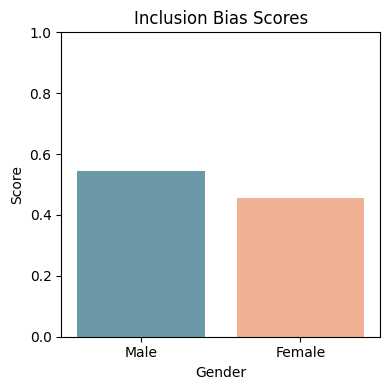

(0.5454545454545454, 0.45454545454545453, -0.09090909090909088)

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

male_terms = {'god', 'gods', 'nephew', 'nephews', 'him', 'baron', 'father', 'fathers' 'dukes', 'dad', 'beau', 'beaus', 'daddies',
        'policeman', 'policemen', 'grandfather', 'landlord', 'landlords', 'monk', 'monks', 'step-son', 'step-sons',
        'milkmen', 'chairmen', 'chairman', 'steward', 'men', 'masseurs', 'son-in-law', 'priest', 'king', 'governor',
        'waiter', 'daddy', 'steward', 'emperor', 'son', 'proprietor', 'groom', 'grooms', 'gentleman', 'gentlemen', 'sir',
        'wizards', 'sorcerer', 'lad','milk-man', 'grandson', 'grand-son','congressmen','dads', 'manager', 'prince', 'stepfathers',
        'boyfriend', 'shepherd', 'shepherds', 'males', 'grandfathers', 'grand-fathers', 'husband', 'usher', 'postman','stags',
        'husbands', 'host', 'boy', 'waiter', 'bachelor', 'bachelors', 'businessmen', 'duke', 'sirs', 'papas', 'heir', 'uncle',
        'princes', 'fiance', 'mr', 'count', 'lords', 'father-in-law', 'actor', 'actors', 'postmaster', 'headmaster', 'heroes',
        'businessman', 'boars','wizard', 'sons-in-law', 'fiances', 'uncles', 'hunter', 'lads', 'masters', 'brother',
        'hosts', 'poet', 'hero', 'grandpa', 'grandpas','manservant', 'heirs', 'male', 'tutors', 'millionaire',
        'congressman', 'sire', 'sires', 'widower','grandsons', 'grand-sons','boys', 'he', 'step-father', 'jewess', 'bridegroom', 'bridegrooms'
        'stepfather', 'widowers', 'abbot', 'mr.,' 'brothers', 'man', 'sons', 'boyfriends', 'he’s', 'his', 'earl',
        'giant', 'stepson', 'stepsons', 'poet', 'mayor', 'peer', 'negro', 'abbot', 'traitor', 'benefactor',
        'instructor', 'conductor', 'founder', 'founders', 'hunters', 'huntresses', 'tempt', 'enchanter', 'enchanters', 'songster',
        'songsters', 'murderer', 'murderers', 'patron', 'patrons', 'author', 'czar', 'guy', 'spokesman', 'spokesmen',
        'pa', 'councilman', 'council-man', 'councilmen', 'council-men', 'gay', 'gays', 'prostate cancer', 'fraternity', 'fraternities', 'salesman', 'dude', 'dudes', 'paternal',
        'brotherhood', 'statesman', 'statesmen', 'countryman', 'countrymen', 'suitor', 'macho', 'papa', 'strongman', 'strongmen',
        'boyhood', 'manhood', 'masculine', 'macho', 'horsemen', 'brethren', 'chap','chaps', 'schoolboy', 'schoolboys', 'bloke',
        'blokes', 'patriarch', 'patriachy', 'fatherhood', 'hubby', 'hubbies', 'fella', 'fellas', 'handyman', 'fraternal',
        'bro', 'masculinity', 'ballerino', 'pappy', 'papi', 'pappies', 'dada', 'bf', 'bfs', 'knights', 'knight',
        'menfolk', 'brotherly', 'manly', 'pimp', 'pimps', 'homeboy', 'homeboys','grandnephew', 'grand-nephew',
        'grand-nephew', 'grand-nephews', 'john doe', 'nobleman', 'noblemen', 'dream boy', 'himself', 'gramps'}
female_terms = {'goddesses', 'niece', 'baroness', 'mother', 'duchesses', 'mom', 'belle', 'belles', 'mummies', 'policewoman',
          'grandmother', 'landlady', 'landladies', 'nuns', 'stepdaughter', 'milkmaids', 'chairwomen', 'stewardesses',
          'women', 'masseuses', 'daughter-in-law', 'priestesses', 'stewardess', 'empress', 'daughter', 'queens',
          'proprietress', 'brides', 'lady', 'queen', 'matron', 'waitresses', 'mummy', 'empresses', 'madam',
          'witches', 'sorceress', 'lass', 'milkmaid', 'granddaughter', 'grand-daughter', 'congresswomen','moms', 'manageress',
          'princess', 'stepmothers', 'stepdaughters', 'girlfriend', 'shepherdess', 'females', 'grand-mothers', 'grandmothers'
          'step-daughter', 'nieces', 'priestess', 'wife', 'mothers', 'usherette', 'postwoman', 'hinds', 'wives',
          'murderess', 'hostess', 'girl', 'waitress', 'spinster', 'shepherdess', 'businesswomen', 'duchess', 'madams', 'mamas',
          'nun', 'heiress', 'aunt', 'princesses', 'fiancee', 'mrs', 'ladies', 'mother-in-law', 'actress', 'actresses',
          'postmistress', 'headmistress', 'heroines', 'bride', 'businesswoman', 'baronesses', 'sows', 'witch',
          'daughters-in-law','aunts', 'huntress', 'lasses', 'mistress', 'mistresses', 'sister', 'hostesses', 'poetess',
          'masseuse', 'heroine', 'goddess','grandma', 'grandmas', 'maidservant', 'heiresses', 'patroness',
          'female', 'governesses', 'millionairess', 'congresswoman', 'dam', 'widow', 'granddaughters', 'grand-daughters', 'headmistresses',
          'girls', 'she', 'policewomen', 'step-mother','stepmother', 'widows', 'abbess', 'mrs.', 'chairwoman', 'sisters',
          'mama', 'woman','daughters', 'girlfriends', 'she’s', 'her', 'maid', 'countess', 'giantess', 'poetess', 'jew',
          'mayoress', 'peeress', 'negress', 'abbess', 'traitress', 'benefactress', 'instructress', 'conductress', 'founder',
          'huntress', 'temptress', 'enchantress', 'songstress', 'murderess', 'murderesses', 'patronesses', 'authoress', 'czarina',
          'spokeswoman', 'spokeswomen', 'ma', 'councilwoman', 'council-woman', 'councilwomen', 'council-women', 'mum', 'lesbian', 'lesbians', 'breast', 'breasts'
          'maiden', 'maidens', 'sorority', 'sororities', 'saleswoman', 'dudette', 'maternal', 'feminist', 'feminists', 'sisterhood',
          'housewife', 'housewives', 'stateswoman', 'stateswomen', 'countrywoman', 'countrywomen', 'chick', 'chicks', 'mommy',
          'strongwoman', 'strongwomen', 'babe', 'babes', 'diva', 'divas', 'feminine', 'feminism', 'gal', 'gals', 'sistren', 'schoolgirl',
          'schoolgirls', 'matriarch', 'matriarchy', 'motherhood', 'wifey', 'sis', 'femininity', 'ballerina', 'ballerinas', 'granny',
          'grannies', 'mami', 'momma', "ma'am", 'gf', 'gfs', 'damsel', 'damsels', 'vixen', 'vixens', 'nan', 'nanny', 'nannies',
          'auntie', 'womenfolk', 'sisterly', 'motherly', 'homegirl', 'homegirls', 'grand-neice', 'grand-neices',
          'grandneice', 'grandneices', 'jane doe', 'noblewoman', 'noblewomen', 'dream girl', 'madame', 'herself', 'hers'}


# -----------------------------
# CORRECT FUNCTION
# -----------------------------
def calculate_weighted_bias(summary, male_terms, female_terms):

    # Join if list
    if isinstance(summary, list):
        summary = ' '.join(summary)

    # Lowercase
    summary = summary.lower()

    # 🔥 KEY FIX: clean tokenization
    words = re.findall(r'\b[a-z]+\b', summary)

    # Frequency count
    word_freq = Counter(words)

    # Count using SAME logic as first method
    male_count = sum(word_freq[word] for word in word_freq if word in male_terms)
    female_count = sum(word_freq[word] for word in word_freq if word in female_terms)

    total = male_count + female_count

    if total > 0:
        male_ratio = male_count / total
        female_ratio = female_count / total
        bias_score = female_ratio - male_ratio
    else:
        male_ratio = female_ratio = bias_score = 0

    # -----------------------------
    # Print results
    # -----------------------------
    print(f" Male Mentions: {male_count}")
    print(f" Female Mentions: {female_count}")
    print(f" Bias Score (female - male): {bias_score:.4f}")

    if bias_score > 0:
        print(" Summary is biased toward females.")
    elif bias_score < 0:
        print(" Summary is biased toward males.")
    else:
        print(" Summary appears neutral.")

    # -----------------------------
    # Optional visualization
    # -----------------------------
    df = pd.DataFrame({
        'Gender': ['Male', 'Female'],
        'Score': [male_ratio, female_ratio]
    })

    plt.figure(figsize=(4,4))
    sns.barplot(x='Gender', y='Score', data=df,
                palette=["#609db0", "#fdac84"])
    plt.title("Inclusion Bias Scores")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()

    return male_ratio, female_ratio, bias_score

combined_summary = [
    "when men start using for gaining mileage or politics vendetta, it defeats the purpose of this social cause! glad that has exposed with her story kindly remember dr jwala, sardars are known for fighting battles for the honour of women!",
    "if this happened to be the other way around, mainstream feminist news channels like would have been running the story all day. this kind of bias will only do more harm to the movement.",
    "the silence is deafening. no for these girls. bbc news - huddersfield grooming: twenty guilty of campaign of rape and abuse",
    "when will men realise that they r digging a well for themselves by false allegations",
    "thanks for being the rare voice in the industry to believe the men who spoke out against him. and thanks specially to for opening the door for others who wanted to speak up. i am not sure this is a victory until she acknowledges the allegations.",
    "i am sure from today onwards, no other men would dare to come out with story. these type of boys never realise, what kind of harm they are doing for movement with this cheap behaviour.",
    "this is the most important piece i've ever written. \"for the most part, mainstream media and so-called lgbt organizations have chosen to ignore a specific demographic of the movement.",
    "when people talk about coming to other countries, don't forget that south asian sex workers, mostly women, have been leading the struggle for sex worker rights globally. for decades. standing up to violence, intimidation in bangladesh and india. for decades.",
    "is not enough. we need to go out against , and other abuse of women. stop protecting , tradition and \"culture\".",
    "at last a former judge has commented reality of . those who level allegations have been in casting couch to reach a position in life. prostitution is a business but these gang are worse than that.",
    "a seattle report found that 94% of native american men surveyed said that they'd been raped or coerced into sex. classical lol discusses who has been erased from the media's coverage of",
    "after couple years of noise, we get celebrities, who ignored the thats rape and abuse problem for decades, lecturing us about a moral responsibility to vote the way they demand.",
    "must be horrible to be female in their southeast_asia where's the brigade? no doubt keeping quiet for the good of diversity.",
    "the first story on talk, hey was mine. the first person i opened up to about having been molested as a child was faizan. please dont believe this attention seeking bully of a woman, faizan has been there for me and countless others even before there was a movement.",
    "university describes a girl's posting his experience of sexual harassment as \" lacking consideration on the big picture\" and \" bringing shame on his university\". interesting.",
    "and it would be because of the actions of a few boys like who abuse , one day it will probably have its own movement as a mark of protest.",
    "more than 1/3 of men have been harassed at some point in their , and in male-dominated jobs the numbers are even higher: via",
    "salmans is an issue of domestic violence. not to be lumped with . diluting the def of will dampen its impact. its def should be restricted to people in power sexually exploiting the weak. not domestic violence or failed relationships",
    "men are constantly unheard until too late. the police failed, irresponsible and allowed another man untimely death .",
    "and to think that i used to find her advice column in the telegraph sunday magazine immensely entertaining. and her outrage over issues like ram rahim etc. man up and face the music. apologise or do what u have to instead of hiding like this.",
    "this looks great but sean penns opinions on the movement and her defense of a prolific sexual predator mean i wont be watching this. shame.",
    "how dare dump, or any of her minions, try to use to stop this investigation. its disgusting!",
    "as i spoke the names of the men who harmed me and recounted every detail of the assaults to journalists, the protective scar tissue over my heart began ripping open. the trauma of my past is now splayed open for all to see. via",
    "holy hell.... not only is trump trying to escape an active effective investigation, she is also trying to mock the movement. repulsive. thank you for bringing this to light. sounds like a lol stone idea.",
    "movement will ensure that the future generations are protected. what happened with us won't happen to enditem all men are devil all men are victims. every case of must be investigated objectively:"
]
# -----------------------------
# RUN
# -----------------------------
calculate_weighted_bias(combined_summary, male_terms, female_terms)